## Phase 1: The Linear Algebra Foundation

### 1. Symmetric Matrices & Covariance

In [5]:
import numpy as np
# Creating the symmetric matrix B
B = np.array([[3, 2, 1], 
              [2, 6, 5], 
              [1, 5, 9]], dtype=float) 

In [6]:
# Verification: If B is symmetric, B - B.T should be a matrix of zeros
print("Symmetry Check (Should be all zeros):\n", B - B.T) 

Symmetry Check (Should be all zeros):
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


### 2. The Dot Product, Norms, and Angles

In [7]:
x = np.array([1 ,2])
y = np.array([-2, 1])

# Scalar product
dot_product = np.dot(x, y)
print("Dot Product:", dot_product)

Dot Product: 0


In [9]:
# Norm/Magnitude
norm_x = np.linalg.norm(x)
norm_y = np.linalg.norm(y)

print("Norm of x:", norm_x)
print("Norm of y:", norm_y)

Norm of x: 2.23606797749979
Norm of y: 2.23606797749979


In [ ]:
# Angle in Radians
theta = np.arccos(dot_product / (norm_x * norm_y))
print("Angle between x and y (radians):", theta)

# Angle in Degrees
theta_degrees = np.degrees(theta)
print("Angle between x and y (degrees):", theta_degrees)

Angle between x and y (radians): 1.5707963267948966
Angle between x and y (degrees): 90.0


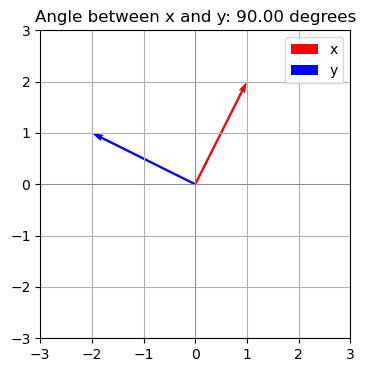

In [13]:
# plotting the angle between x and y using matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4))
plt.quiver(0, 0, x[0], x[1], angles='xy', scale_units='xy', scale=1, color='r', label='x')
plt.quiver(0, 0, y[0], y[1], angles='xy', scale_units='xy', scale=1, color='b', label='y')
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.grid()  
plt.legend()
plt.title(f"Angle between x and y: {theta_degrees:.2f} degrees")
plt.show()

In [15]:
# If 0, vectors are orthogonal (90 degrees)

if np.isclose(dot_product, 0):
    print("Vectors x and y are orthogonal.")
else:
    print("Vectors x and y are not orthogonal.")

Vectors x and y are orthogonal.


### 3. Eigen-decomposition ($B u = \lambda u$)

In [ ]:
print(B)

[[3. 2. 1.]
 [2. 6. 5.]
 [1. 5. 9.]]


In [18]:
## D contains Eigenvalues, U contains Eigenvectors (columns)
D, U = np.linalg.eig(B)

print("Eigenvalues (Variance strength):\n", D) 
print("Eigenvectors (Principal directions):\n", U) 

Eigenvalues (Variance strength):
 [13.11766327  3.44324229  1.43909444]
Eigenvectors (Principal directions):
 [[-0.19527095 -0.74608451  0.63657455]
 [-0.59990492 -0.42261825 -0.67934373]
 [-0.77587586  0.5145403   0.3650547 ]]


In [19]:
# Verification 1: Orthogonality
# The dot product of two different eigenvectors (columns) should be 0
dot_check = np.dot(U[:, 0], U[:, 1]) 
print(f"Dot product of U[:,0] and U[:,1]: {dot_check:.10f}") # Should be ~0 

Dot product of U[:,0] and U[:,1]: -0.0000000000


In [20]:
# Verification 2: Orthonormality (The "Crucial Observation")
# For a symmetric matrix, U * U.T should equal the Identity Matrix (I)
identity_check = np.dot(U, U.T) 
print("U @ U.T (Should be Identity Matrix):\n", np.round(identity_check))

U @ U.T (Should be Identity Matrix):
 [[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]


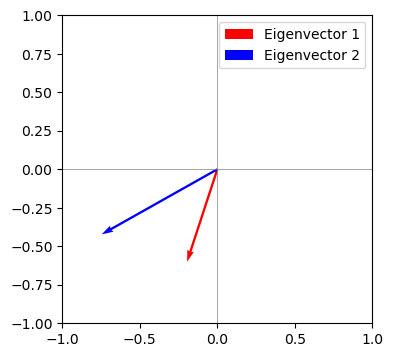

In [22]:
# plot this using matplotlib
plt.figure(figsize=(4, 4))
plt.quiver(0, 0, U[0, 0], U[1, 0], angles='xy', scale_units='xy', scale=1, color='r', label='Eigenvector 1')
plt.quiver(0, 0, U[0, 1], U[1, 1], angles='xy', scale_units='xy', scale=1, color='b', label='Eigenvector 2')
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.legend()
plt.show()

## Phase 2: Randomness & The Central Limit Theorem

### 1. Uniform Distribution "Noise"

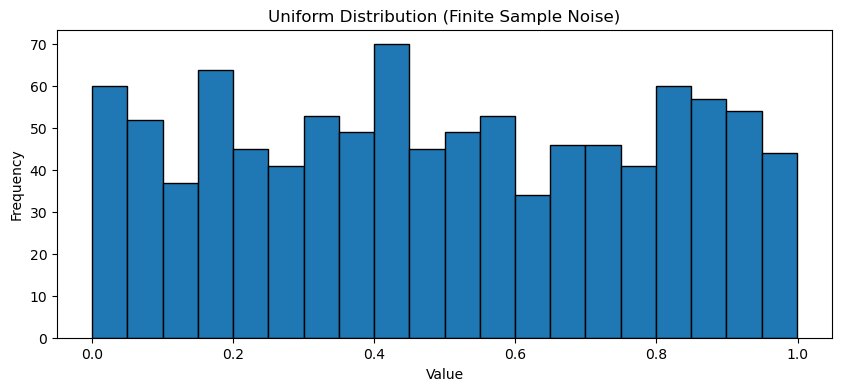

In [28]:
# Generate 1000 uniform random numbers between 0 and 1 
data = np.random.rand(1000)
# Plot histogram of the data
plt.figure(figsize=(10, 4))
plt.hist(data, bins=20, edgecolor='black')
plt.title("Uniform Distribution (Finite Sample Noise)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

### 2. The "Sum of 12" Trick (Creating a Gaussian)

In [32]:
N_samples = 10000
summed_data = np.zeros(N_samples)

print("summed_data:", str(summed_data))

summed_data: [0. 0. 0. ... 0. 0. 0.]


summed_data after summation: [-1.27417611 -0.38951168  1.20825644 ... -0.72217604  2.55087226
 -0.11967571]


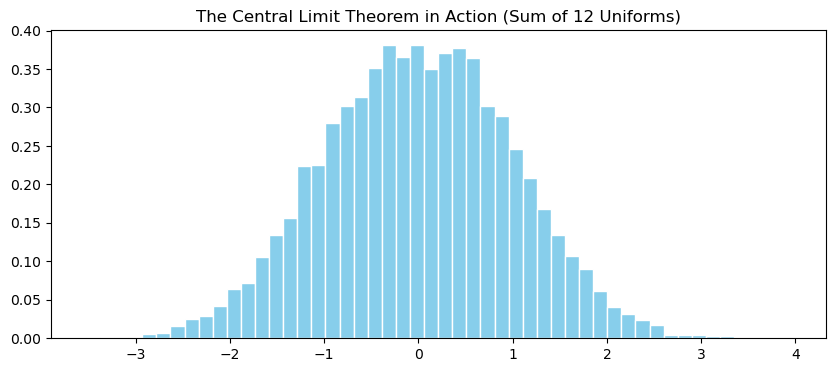

In [ ]:
for i in range(N_samples):
    # Summing 12 uniform random numbers
    summed_data[i] = np.sum(np.random.rand(12)) - 6

print("summed_data after summation:", str(summed_data))

# Plot histogram of the summed data
plt.figure(figsize=(10, 4))
plt.hist(summed_data, bins=50, density=True, color='skyblue', edgecolor='white')
plt.title("The Central Limit Theorem in Action (Sum of 12 Uniforms)")
plt.show()


### 3. Uncertainty in Estimation

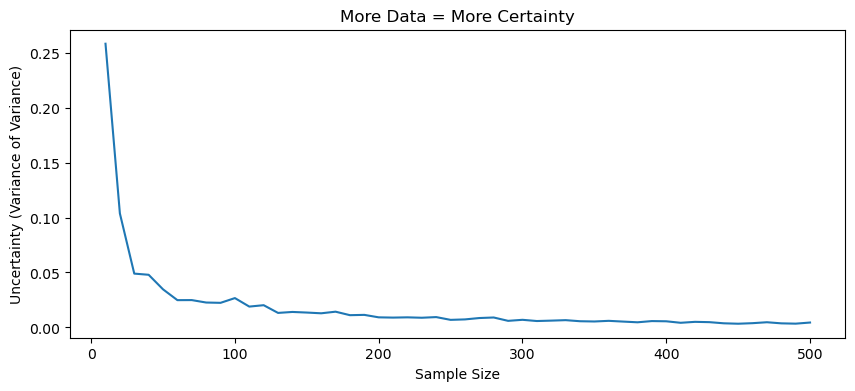

In [52]:
sample_sizes = np.linspace(10, 500, 50).astype(int)

variations = []
for size in sample_sizes:
    trial_variances = [np.var(np.random.randn(size)) for _ in range(100)]
    variations.append(np.var(trial_variances)) # How much does our estimate "wiggle"? 

plt.figure(figsize=(10, 4))
plt.plot(sample_sizes, variations)
plt.xlabel("Sample Size")
plt.ylabel("Uncertainty (Variance of Variance)")
plt.title("More Data = More Certainty")
plt.show()

## Phase 3: Multi-variate Gaussian Properties

### 1. Sampling with Cholesky Decomposition

#### The Theory

The property states: $x \sim \mathcal{N}(m, C)$ and $y = Ax \Rightarrow y \sim \mathcal{N}(Am, ACA^T)$.
To get a specific $C$, we find $A$ such that $AA^T = C$. This is what Cholesky Decomposition does.

In [57]:
# 1. Define Mean and Covariance 
m = np.array([0, 0])
C = np.array([[2.0, 1.0], 
              [1.0, 2.0]])

In [59]:
# 2. Cholesky Factorization 
# A is a lower triangular matrix such that A @ A.T = C
A = np.linalg.cholesky(C)
print("Cholesky Factor A:\n", str(A))

Cholesky Factor A:
 [[1.41421356 0.        ]
 [0.70710678 1.22474487]]


Standard Normal Noise Samples (First 5):
 [[ 1.58689329 -1.37341684]
 [ 0.41876812 -1.6321681 ]
 [-0.84317665  0.70614098]
 [ 0.89899822  0.13106185]
 [ 0.53686954 -0.39673495]]


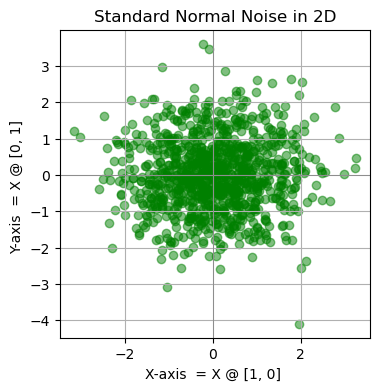

In [65]:
# 3. Generate Standard Normal Noise 
# 1000 samples in 2D space
X = np.random.randn(1000, 2)
print("Standard Normal Noise Samples (First 5):\n", X[:5])

#plot the noise samples
plt.figure(figsize=(4, 4))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, color='green')
plt.title("Standard Normal Noise in 2D")
plt.xlabel("X-axis  = X @ [1, 0] ")
plt.ylabel("Y-axis  = X @ [0, 1] ")
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.grid()
plt.show()  


Cholesky Factor A:
 [[1.41421356 0.        ]
 [0.70710678 1.22474487]]
Transformed Data (First 5):
 [[ 2.24420601 -0.55998223]
 [ 0.59222756 -1.70287573]
 [-1.19243185  0.26862662]
 [ 1.27137547  0.79620506]
 [ 0.75924818 -0.106275  ]]


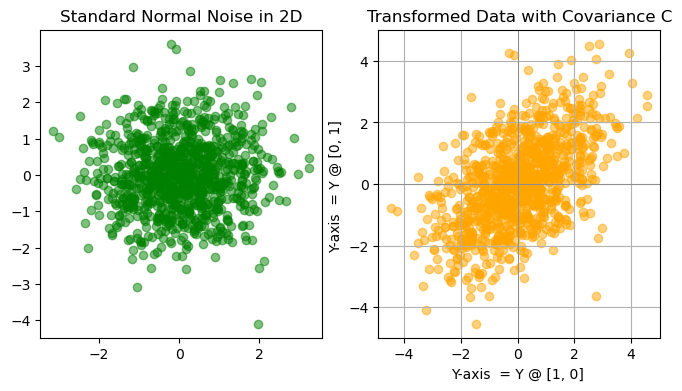

In [73]:
# 4. Transform the data 
# This 'stretches' the circular noise into the elliptical Gaussian
print("Cholesky Factor A:\n", str(A))
Y = X @ A.T
print("Transformed Data (First 5):\n", Y[:5])

# Plot the transformed data and the befor and after covariance transformation
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, color='green')
plt.title("Standard Normal Noise in 2D")
plt.subplot(1, 2, 2)
plt.scatter(Y[:, 0], Y[:, 1], alpha=0.5, color='orange')
plt.title("Transformed Data with Covariance C") 
plt.xlabel("Y-axis  = Y @ [1, 0] ")
plt.ylabel("Y-axis  = Y @ [0, 1] ")
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.grid()
plt.show()



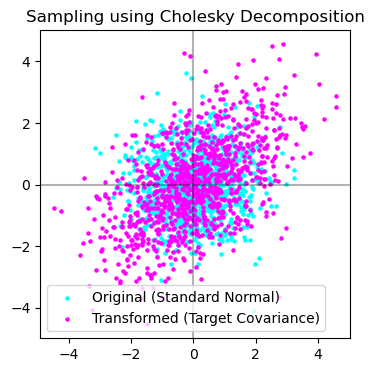

In [74]:
# Visualizing the transformation [cite: 171, 172, 175, 176]
plt.figure(figsize=(4,4))
plt.scatter(X[:,0], X[:,1], c='cyan', s=5, label='Original (Standard Normal)')
plt.scatter(Y[:,0], Y[:,1], c='magenta', s=5, label='Transformed (Target Covariance)')
plt.axhline(0, color='black', alpha=0.3)
plt.axvline(0, color='black', alpha=0.3)
plt.legend()
plt.title("Sampling using Cholesky Decomposition")
plt.show()

### 2. Projected Variance (The "Why")

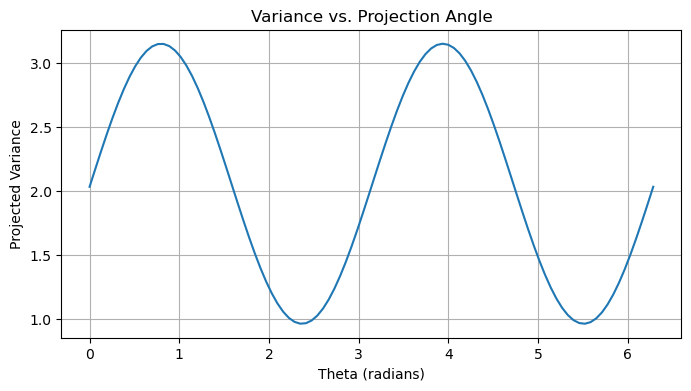

In [ ]:
n_points = 100
thetas = np.linspace(0, 2*np.pi, n_points) 
projected_variances = []

for theta in thetas:
    # Construct unit vector u 
    u = np.array([np.sin(theta), np.cos(theta)])
    
    # Project data: yp = Y @ u 
    projected_data = Y @ u
    
    # Calculate and store variance 
    projected_variances.append(np.var(projected_data))

# Plot the relationship 
plt.figure(figsize=(8,4))
plt.plot(thetas, projected_variances)
plt.xlabel("Theta (radians)")
plt.ylabel("Projected Variance")
plt.title("Variance vs. Projection Angle")
plt.grid(True)
plt.show()

In [77]:
# Compute Eigenvalues of C 
evals, evecs = np.linalg.eig(C)

print(f"Largest Eigenvalue: {np.max(evals)}")
print(f"Max Projected Variance from Plot: {np.max(projected_variances)}")
# These two values should be almost identical!

Largest Eigenvalue: 3.0
Max Projected Variance from Plot: 3.152294470693873
